Quinlan Day | qbd@uw.edu

CFRM 522: Advanced Trading Systems

Paper Replication Project:

**NGAT: A Node-level Graph Attention Network for Long-term Stock Prediction**

by Yingjie Niu, Mingchuan Zhao, Valerio Poti, and Ruihai Dong

# Summary of Research

## Logic
Graph Neural Networks (GNNs) are currently the dominant model for graph representation learning because they are able to learn how to contextually build a graph structure with its neighboring nodes. The new use of GNN models have increased interest in capturing momentum spillover affects, which uses companies as nodes and inter-company relationships as edges. Current GNNs typically follow the same structure; generate corporate relational graph (CRG) to produce edges, apply GNN to the company relationship graph, then evaluate your performance. However, this is unwise because of three reasons:

1. Momentum spillover is not instant. Most Graph based prediction studies focus on next-day results, which do not utilize the most of what GNNs are capable of. Most studies focus on future returns rather than volatility, a very crucial matter for a trivial analysis. NGAT predicts stock volatility using relational graphs and historical data, providing a better analysis for true investors.

2. Many known graph network models such as a Graph Convolutional Network (GCN) or Graph Attention Network (GAT) may not be suited to corporate relational graphs. In conventional GCNs and GATs nodes share similar distributions, but since we desire modeling corporations as nodes it is extremely presumptuous to assume all companies share the same distribution. Although there are current models using companies as nodes, the models are extremely specific, reducing its generalizeability. NGAT assigns each node an attention mechanism to assist momentum spillover modeling, which allow it to use corporate relational graphs without heavy assumptions.

3. The creation of CRGs are primarily based on experience and not quantitative methods. They compare the result and accuracy of identical GNN models with different model construction, which demonstrates the inaccuracies of using down stream performance to evaluate the graph generated.

## Problem Formulation

To begin we classify the return label $y^{s}_{d,c}$ using the below equation, with $d$ as the day, $T$ as the future amount of days to generate return and volatility over (period length), $r$ is the log return of stock $s$ on day $i$, where $c$ is the categorization of the return trends into one of the following four scenarios:
1. (LP, N+) Last period positive return followed by a positive return surge.
2. (LN, N+) Last period negative return followed by a positive return surge.
3. (LP, N-) Last period positive return followed by a negative return surge.
4. (LN, N-) Last period negative return followed by a negative return surge.

$$
y_{d,c}^{s}
= \mathbf{1}\!\left(
\frac{1}{T}\sum_{i=d+1}^{d+T} r_i^{s}
>
\frac{1}{T}\sum_{i=d-T+1}^{d} r_i^{s}
\right)
$$


We write the standard deviation label $y^s_{d,r}$ formula which is part of the regression result focused on the exact value of volatility in the upcoming $T$ days and $\mu$ is the mean of log returns over the period $[d+1,d+T]$

$$
y^{s}_{d,r}=\sqrt{\frac{1}{T}\sum^{d+T}_{i=d+1}(r^{s}_{i}-\mu)^2}, \mu = \frac{1}{T}\sum^{d+T}_{i=d+1}r^s_i
$$

The $r$ value is similar to $c$, where it is one of four values:
1. (LN, N+) Last period increased standard deviation, standard deviation increased in the future.
2. (LP, N+) Last period decreased standard deviation, standard deviation increased in the future.
3. (LN, N-) Last period increased standard deviation, standard deviation decreased in the future.
4. (LP, N-) Last period decreased standard deviation, standard deviation decreased in the future.

The conclusion of the NGAT paper is that NGAT has the following values using overall accuracy of classifying the return prediction (ACC), the Matthews Correlation Coefficient (MCC), and the area under the ROC, Receiver Operating Characteristics, curve (AUC). The way each metric is calculated uses the confusion matrix $\begin{pmatrix} TP & TN \\ FP & FN \end{pmatrix}$ where TP, TN, FP, FN represent true positive, true negative, false positive, and false negative respectively. Although the original paper only uses ACC, MCC, and AUC, I will add precision and recall to the analysis. <br>
Accuracy measures how often the model is correct overall. The area under the ROC is a common metric for graph neural network classifiers, quantifying performance across all thresholds. AUC, the area under ROC, measures the overall ability of a model to distinguish between positive and negative classifications. While the Matthews Correlation Coefficient is a binary classification metric that measures the correlation between predicted and real stock movements. Precision measures how often the model accurately predicts positive, and recall (TPR) measures how often the model catches a true positive.  

$$
ACC = \frac{TP + TN}{TP + TN + FP + FN}
$$

$$
TPR = \frac{TP}{TP+FN},
FPR = \frac{FP}{FP+TN}
$$
$$
AUC =\int ^1_0TPR(FPR)d(FPR)
$$

$$
MCC = \frac{TP\times TN - FP\times FN}{\sqrt{(TP+FN)+(TP+FP)+(TN+FN)+(TN+FP)}}
$$

The following results are what were claimed in the original and what will be shown in this file.

r-meanX denotes T=X classification for return mean prediction performance.

| Dataset | r-mean1 (ACC/MCC/AUC) | r-mean5 (ACC/MCC/AUC) | r-mean10 (ACC/MCC/AUC) | r-mean21 (ACC/MCC/AUC) |
|--------|----------------------|----------------------|-----------------------|-----------------------|
| ACL2018 | 0.7395 / 0.3825 / 0.8370 | 0.7774 / 0.4150 / 0.8172 | 0.7745 / 0.3652 / 0.7849 | 0.7063 / 0.3790 / 0.8082 |
| SPNews | 0.7627 / 0.4835 / 0.8407 | 0.7504 / 0.4711 / 0.8296 | 0.7384 / 0.4462 / 0.8326 | 0.7397 / 0.4168 / 0.8142 |


| Dataset | Scenario | r-mean5 LN         | r-mean5 LP         | r-mean10 LN        | r-mean10 LP        | r-mean21 LN        | r-mean21 LP        |
| ------- | -------- | ------------------ | ------------------ | ------------------ | ------------------ | ------------------ | ------------------ |
| ACL2018 | N+       | 622/801 (0.7765)   | 731/893 (0.8186)   | 465/630 (0.7380)   | 750/911 (0.8232)   | 355/467 (0.7601)   | 491/633 (0.7756)   |
| ACL2018 | N-       | 831/1039 (0.7998)  | 770/1067 (0.7216)  | 794/996 (0.7971)   | 934/1263 (0.7395)  | 711/1027 (0.6923)  | 1091/1673 (0.6512) |
| SPNews  | N+       | 1734/2379 (0.7288) | 1648/2433 (0.6773) | 1694/2461 (0.6888) | 1269/1906 (0.6657) | 1844/2667 (0.6914) | 624/1106 (0.5804)  |
| SPNews  | N-       | 2040/2537 (0.8040) | 2220/2835 (0.7830) | 2035/2610 (0.7796) | 2522/3207 (0.7864) | 2667/3445 (0.7741) | 2380/2966 (0.8024) |


I will be testing to see if my accuracy and analytics output matches their output and verify their hypothesis of their proposed NGAT model outperforming LSTM through various machine learning prediction metrics. Unfortunately, no data sets similar to this exist, as most of them are formatted into one massive file and would need to be broken down into separate JSON files to update the data. Additionally, my computer has memory issues, so the current outputs are only for the existing rmean and cannot predict std. 

## Obtaining and Generating Data

The authors use two data sets to compare their model; ACL2018 and SPNews. Both data sets are different in how they were obtained, are used for separate analysis of the model, and are from two separate time periods of different lengths. Neither data sets are available for generation or addition, since the ACL2018 data set is simply a GitHub folder with csv files, and SPNews gives code, but the code is only generated via an excel document on the original author's computer. 

The data ACL2018 was obtained from the GitHub folder for Stock Movement Prediction from Tweets and Historical Prices [1]. The ACL 2018 data set contains price data and tweet data from January 1st 2014 to January 1st 2016. The 88 stocks chosen are the top 10 stocks in each of the following 11 industries; Basic Materials, Consumer Goods, Healthcare, Services, Utilities, Conglomerates, Financial, Industrial Goods, and Technology.

The data SPNews was obtained from the Github folder for Evaluating Financial Relational Graphs: Interpretation Before Prediction [2]. This data includes the price data and the most recent 8 yahoo finance news articles for each S&P500 company from September 20th 2022 to May 20th 2024. Although it is not mentioned in the article, the primary authors for the original paper that proposed the SPNews data set and this NGAT paper are the same. <br>
One issue with the SPNews data set is its weakness in generating accurate nodes. It includes only the most recent mention of any stock, for example, "Top 10 Stocks Our Analysts Have Picked For Your Portfolio" will generate as relational news for any stocks that happen to be in there, regardless of their true relationship or even industry, even if it takes over an important industry specific article that more accurately models the CRG. 

If the model is to be rerun, run main.py to generate the model, then predict.py to generate predictions, main_classification.py to generate data sets from prediction, then data_review and output_review in NGAT/code/notebook. Make sure main, predict, and main_classification all are run on all combination of data sets (ACL2018, SPNews) and predictors (mean, std).

# Literature Review

The authors believe that as of lately, the existing research in stock prediction evolve along two lines; modelling new tasks using machine learning rather than traditional econometrics, and applying generic models to financial-specific problems. Their argument is that most of the research follows the same few trends:<br>
<br>
The consistent research topics of stock prediction from econometrics consists of factor analysis [3], time-series analysis [4], and volatility modeling using either Generalized Autoregressive Conditional Heteroskedasticity (GARCH) [5] or Heterogenous Autoregressive model of Realized Volatility (HAR-RV) [6]. The latest research in machine learning either combine multiple models such as GARCH and neural-networks [7] or use sequence models like Least-Short Term Memory (LSTM) [8]. Most models have focused on next-day prediction, however recent advancements have moved towards ranking tasks [9], trend prediction [10], and price-limit forecasting[11]. Since models have mostly focused on next-day prediction, NGAT claims superiority due to its long-term forecasting power and ability to capture momentum spillover.<br>
Availability and convenience of new kinds of data have sparked graph-based models such as Graph Attention Networks (GAT) [12] and Graph Convolution Networks (GCN) [13] which are able to model inter-firm correlational relationships through prices, news, social media, and industry-classification. Adaptation to different domains introduced Temporal Graph Neural Network (GNN) models [14], Attribute Drive Graph Attention Networks (AD-GAT) [15], and hierarchal GNNs [11], however these models are increasingly complex and not generalizeable due to their specificity. NGAT proposes a node-specific attention network model that is designed to erase these issues. <br>
LSTM, GCN, GAT, LSTM+GCN, TGC, and AD-GAT models are all generated in the code and used for prediction and comparison as benchmarks. The implementation of these packages were done through PyTorch, an open-source python deep learning library, as well as various other packages to assist with other tasks (sys, pandas, counter, etc). 


# Model Architecture

## Building Relational Edges

Edges are quantified by the number of co-occurances between firms in the news. The firm mentioned is extracted from each article, $n^k_d$ (k-th news article on day d), then $R^{(s_i,s_j),k}_d=1$ for all company combinations in the article. Daily aggregation yields the relational attributes: $R^{(s_i,s_j)}_d=\sum^K_{k=1}R^{(s_i,s_j),k}_d$, where the attribute given to the node is $R^{(s_i)}_d=max_{j∈\N _i}R^{s_i,s_j}_d$ where $\N _i$ is the neighbors of node $s_i$. To model news effects over time and prioritize recency, temporal weighting $w$ to apply to the attribute on day $d-m$ is added to reflect time decay, where $\delta$ is the memory window size. 
$$
\hat{R}^{(s_i,s_j)}_d=\sum^{\delta - 1}_{m=0}w_m·R^{(s_i,s_j)}_{d-m}, w_m = \frac{\delta-m}{\sum^{\delta}_{n=1}n}
$$

NGAT transforms inputs to outputs using the following math. Let $\bold{h}=\{h^1_d,...,h^N_d\} (h^i_d∈\R^F)$ denote sequential embeddings of $N$ nodes. Each node applies three linear projections, $\bold{W}_q,\bold{W}_k,\bold{W}_v∈\R^{F'\times F}$. Masked attention for the edge between node $i,j$ is computed using $a_i$ denoting node i's attention mechanism matrix:
$$
e_{ij}=\hat{R}_d^{(i,j)}·a_i(\bold{W}_qh^i,\bold{W}_kh^j), j∈\N _i
$$

Attention weights are normalized so that all attention values across neighbors sum to 1:
$$
\beta _{ij}=Softmax_i(e_{ij})=\frac{exp(e_{ij})}{\sum _{m∈\N _i} exp(e_{im})}
$$

Incorporating the previous two equations with LeakyReLu, a nonlinear function applied to neural networks with slope ($\alpha$)=0.2, using $^T$ for transpose, $a_i$ as the attention matrix of node $i$, and || representing the concatenation operation:
$$
LeakyReLu(x) = \begin{cases} x,&  x \gt 0 \\ \alpha x,& x \le 0 \end{cases}
$$
$$
\beta_{ij}=\frac{exp(\hat{R}_d^{(i,j)}LeakyReLu(\bold{a}_i^T[\bold{W}_qh^i || \bold{W}_kh^j]))}{\sum_{m∈\N _i}exp(\hat{R}_d^{(i,m)}LeakyReLu(\bold{a}_i^T[\bold{W}_qh^i || \bold{W}_kh^m]))}
$$

With neighbor influence as $\sum_{j\in \N _i}\beta_{ij}\bold{W}_v$, we can make the vector of features $\hat{h}$ using $\sigma$ as the nonlinear projection through the network, and $\bold{W}$ as the weighting matrix for neighbor info:
$$
\hat{h}^i = \sigma(\bold{W}[\bold{W}_vh^i||\sum _{j \in \N _i} \beta_{ij}\bold{W}_vh^j]), \bold{W} \in \R^{F'\times 2F'}
$$

Each head m produces its own $\hat{h}_i^{(m)} \in \R^{F'}$, which are stacked side by side to create $\hat{h'}_i \in \R^{M\cdot F'}$ to ensure stability in learning via concatenated outputs, calculated using the formula below.
$$
\hat{{h}}^{\prime i}=||^M_{m=1}\sigma (\bold{W^m}[\bold{W}^m_vh^i||\sum _{j\in \N _i}\beta^m_{ij}\bold{W}^m_vh^j])
$$
If using average:
$$
\hat{{h}}^{\prime i}=\sigma (\frac{1}{M}\sum ^M_{m=1}\bold{W^m}[\bold{W}^m_vh^i||\sum _{j\in \N _i}\beta^m_{ij}\bold{W}^m_vh^j])
$$

## Final Output Prediction

The output is then parameterized by weight matrix $\bold{W}_o$ and defined by:
$$
\hat{y}^i = \begin{cases} \bold{W}_o \hat{h}^{\prime i} & (\text{regression result}) \\ Sigmoid(\bold{W}_o \hat{h}^{\prime i}) & (\text{classification}) \end{cases}
$$
$$
\text{Sigmoid($z$)} = \frac{1}{1+e^{-z}}
$$

Where $\hat{y}^y$ is either the regression prediction result or the classification output containing a probability between 0 and 1 of the firm having a positive event.

## Future Research

The main problem in this research was the data set. Given the ACL2018 dataset was created by this paper's primary author, it should have been easy to rewrite the code for newer scraping, but they used a dataset from 2014-2016 for convenience. If future research is done, it should be classified as either an article relevant to the company directly (not a "top 10 stocks" article) or not. In the Jupyter file "data_review.ipynb" under code/notebook/ it seems the authors tried to generate their relational values by using an LLM assuming the role of financial text advisor. <br>
Incorporating different media (Twitter, Facebook, News, Reddit, etc.) and assigning them weights which lower variance can greatly improve the model. The original paper for NGAT does not combine ACL2018 and SPNews to try and train the model for both datasets, then attempt prediction for ACL2018 and SPNews, which would have been interesting to see. Continually changing the correlation value or giving a better time window estimate would also improve the model output. 

# References
[1] [Stock Movement Prediction from Tweets and Historical Prices](https://aclanthology.org/P18-1183/) (Xu & Cohen, ACL 2018) <br>
[2] [Evaluating Financial Relational Graphs: Interpretation Before Prediction](https://dl.acm.org/doi/abs/10.1145/3677052.3698644) (Niu, Lu, Dolphin, Doti & Dong 2024)<br>
[3] [Factor Analysis: a means for theory and instrument development in support of construct validity](https://pmc.ncbi.nlm.nih.gov/articles/PMC7883798/) (Tavakol & Wetzel 2020) <br>
[4] [Advanced Stock Market Prediction Using Long Short-Term Memory Networks: A Comprehensive Deep Learning Framework](https://arxiv.org/html/2505.05325v1) (Chaudhary & Kumar 2025) <br>
[5] [GARCH 101: An Introduction to the Use of ARCH/GARCH models in Applied
Econometrics](https://web-static.stern.nyu.edu/rengle/GARCH101.PDF) (Engle) <br>
[6] [A Simple Long Memory Model of Realized Volatility](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=626064) (Corsi 2004) <br>
[7] [Forecasting the volatility of stock price index: A hybrid
model integrating lstm with multiple garch-type models. Expert Systems with
Applications](https://www.sciencedirect.com/science/article/pii/S0957417418301416) (Kim & Won 2018) <br>
[8] [Enhancing Stock Market Prediction with LSTM: A Review of Recent Developments and Comparative Analysis](https://doi.org/10.1007/s11831-025-10370-0) (Hafshejani & Mansouri 2025)<br>
[9] [Temporal Relational Ranking for Stock Prediction](https://dl.acm.org/doi/pdf/10.1145/3309547) (Feng, He, Wang, Luo, Liu & Chua 2019)<br>
[10] [A Distillation-based Future-aware Graph Neural
Network for Stock Trend Prediction](https://arxiv.org/pdf/2502.10776) (Liu, Duan, Geng & Zhang 2025)<br>
[11] [HGNN: Hierarchical graph neural network for predicting the classification of price-limit-hitting stocks](https://www.sciencedirect.com/science/article/abs/pii/S0020025522005928) (Xu, Huang, Ying, Gao, Li, Zhang, Xiao, Zhang & Luo 2022)<br>
[12] [Large-scale Time-Varying Portfolio Optimisation using Graph Attention Networks](https://doi.org/10.48550/arXiv.2407.15532) (Korangi, Mues & Bravo 2025)<br>
[13] [GCNET: graph-based prediction of stock price movement using graph convolutional network](
https://doi.org/10.48550/arXiv.2203.11091) (Jafari & Haratizadeh 2022)<br>
[14] [Temporal and Heterogeneous Graph Neural Network for Financial Time Series Prediction](
https://doi.org/10.1145/3511808.3557089) (Xiang, Cheng, Shang, Zhang & Liang 2023)<br>
[15] [Modeling the Momentum Spillover Effect for Stock Prediction via Attribute-Driven Graph Attention Network](https://doi.org/10.1609/aaai.v35i1.16077) (Cheng & Li 2021)

# Code

Import libraries, other python files, and define paths. Set machine learning program to use GPU if compatable with torch (NVIDIA graphics card) for much faster performance otherwise use CPU.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm
import torch
import ast
import sys 
import itertools
from collections import Counter
import yfinance
from torch.utils.data import Dataset
import seaborn as sns
import warnings
import gc
from scipy import stats
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, matthews_corrcoef


ROOT_FOLDER = os.path.abspath(os.path.join(os.getcwd(), "522 Replication Code", "NGAT")) + os.sep
print(ROOT_FOLDER)
GRAPH_BUILDING_DIR = os.path.join(ROOT_FOLDER, "code", "graph_building")

print("GRAPH_BUILDING_DIR:", GRAPH_BUILDING_DIR)
print("Exists?:", os.path.exists(GRAPH_BUILDING_DIR))

sys.path.append(GRAPH_BUILDING_DIR)
print(sys.path)
from edge_generator import EdgeGenerator
from node_generator import NodeGenerator
from graph_generator import GraphGenerator
from firmgraph_dataset import FirmRelationGraph

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device, torch.cuda.device_count()

c:\Users\quinb\Desktop\UW CFRM\522\Research Paper 1\522 Replication Code\NGAT\
GRAPH_BUILDING_DIR: c:\Users\quinb\Desktop\UW CFRM\522\Research Paper 1\522 Replication Code\NGAT\code\graph_building
Exists?: True
['c:\\Users\\quinb\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'c:\\Users\\quinb\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'c:\\Users\\quinb\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'c:\\Users\\quinb\\AppData\\Local\\Programs\\Python\\Python313', '', 'C:\\Users\\quinb\\AppData\\Roaming\\Python\\Python313\\site-packages', 'c:\\Users\\quinb\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages', 'c:\\Users\\quinb\\Desktop\\UW CFRM\\522\\Research Paper 1\\522 Replication Code\\NGAT\\code\\graph_building']
4


(device(type='cpu'), 0)

## ACL Data Set

Set file paths.

In [2]:
ACL_building = os.path.join(ROOT_FOLDER, "data", "raw", "ACL2018")

acl18_fp = ACL_building + "/"
acl18_price_raw = acl18_fp+"price/raw/"
acl18_tweet_preprocessed = acl18_fp+"tweet/preprocessed/"

Generate and print a list of tickers with dates outside of PERIOD_START and PERIOD_END.

In [3]:
PERIOD_START = '2014-01-02'
PERIOD_END = '2015-12-31'
firms = []
for ticker_folder in os.listdir(acl18_tweet_preprocessed):
    if ticker_folder[0] != '.':
        tweet_list = os.listdir(acl18_tweet_preprocessed+ticker_folder)
        if sorted(tweet_list)[0][:7] != '2014-01':
            if ticker_folder not in firms:
                firms.append(ticker_folder)
        if sorted(tweet_list)[-1][:7] != '2015-12':
            if ticker_folder not in firms:
                firms.append(ticker_folder)
        

We are interested in the stock return over M days (5, 10, 21)

In [4]:
def generate_target_for_one_stock(csv_f, estimation_window=100, dataset='acl2018'):
    """
    Input: a price dataframe of one stock, estimation window length, dataset name
    Output: a dataframe with the prediction targets as columns
    """
    steps = [5,10,21]
    if dataset=='acl2018':
        # log return = 100 * r(t+1)/r(t)
        csv_f['log return'] = 100 * np.log(csv_f['Adj Close']/csv_f['Adj Close'].shift(1))
        begin_idx = csv_f[csv_f['Date']==PERIOD_START].index[0]
        end_idx = csv_f[csv_f['Date']==PERIOD_END].index[0]
        # for each step length, calculate the r_mean and std of log returns
        for m in steps:
            csv_f['r_mean'+str(m)] = csv_f['log return'].shift(-m).rolling(window=m).mean()
            csv_f['std'+str(m)] = csv_f['log return'].shift(-m).rolling(window=m).std()
        if begin_idx < estimation_window:
            raise ValueError(f'Historical data length not enough. There are {begin_idx} days ahead of 2014-01-02!')
    return csv_f.iloc[begin_idx:end_idx]

Read tweets function

In [5]:
def read_day_tweet(tweet_fp):
    """
    Read the tweets file of a firm on a single day.
    Input: tweet file path
    Output: return a list of dicts of tweets on this day
    """
    with open(tweet_fp,'r') as f:
        tweets = []
        for line in f:
            line_dict = json.loads(line)
            tweets.append(line_dict)
    return tweets

Test Graph Generators

In [6]:
#S&P500 index data
raw_data = yfinance.download (tickers = "^GSPC", start = "2022-05-31", 
                              end = "2024-05-21", interval = "1d")


#Build dataset
dataset = FirmRelationGraph(
    dynamic="cooccur",
    num_node_features=8,
    matrix_node_features=True,
    node_normalize='mean',
    num_Y_features=4,
    Y_type="mean",
    classification=True,
    graph_level_task=False,
    estimation_window=21,
    num_edge_features=1,
    weighted_edge=True,
    threshold=1,
    root = os.path.join(ROOT_FOLDER, "data", "graph_sets"),
    name="ACL2018"
)


[*********************100%***********************]  1 of 1 completed


Generator for ACL2018 is initialized ...
Total Firms:  86 , Valid Firms:  76 , Incomplete Record Firms:  76
504 trading days.  698 natual days.


Train and test network

In [7]:
dev_len, test_len = int(len(dataset)/10), int(len(dataset)/10)
train_len = len(dataset)-dev_len-test_len

_ = dataset.graphgenerator.build_graph()
last_period = dataset.graphgenerator.last_period
keys = list(last_period.keys())

100%|██████████| 504/504 [01:00<00:00,  8.37it/s]

Total missing node features for graph-level task: 38304


Read S&P500 data from ACL2018

In [8]:
import os, pandas as pd, numpy as np

ng = dataset.graphgenerator.node_generator
csv_path = os.path.join(ROOT_FOLDER, "data", "raw", "ACL2018", "sp500index.csv")
print("Using:", os.path.abspath(csv_path))
print(csv_path)
assert os.path.exists(csv_path), "CSV not found — adjust csv_path"

df = pd.read_csv(csv_path)
df['log return'] = 100 * np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# apply the same preprocessing used in the class
df = ng.rescale(df)

for m in ng.steps:
    df['r_mean'+str(m)] = df['log return'].shift(-m).rolling(window=m).mean()
    df['std'+str(m)] = df['log return'].shift(-m).rolling(window=m).std()
    df['p_mean'+str(m)] = df['Adj Close'].shift(-m).rolling(window=m).mean()
    df['hist_rmean'+str(m)] = df['log return'].rolling(window=m).mean()
    df['hist_std'+str(m)] = df['log return'].rolling(window=m).std()
    df['hist_pmean'+str(m)] = df['Adj Close'].rolling(window=m).mean()

begin_idx = df['Date'].index[0]
end_idx = df['Date'].index[0]
target_df = df.iloc[begin_idx - 2*ng.estimation_window + 1:end_idx].reset_index(drop=True)

ng.graph_target_df = target_df
print("graph_target_df initialized with", len(ng.graph_target_df), "rows")

Using: c:\Users\quinb\Desktop\UW CFRM\522\Research Paper 1\522 Replication Code\NGAT\data\raw\ACL2018\sp500index.csv
c:\Users\quinb\Desktop\UW CFRM\522\Research Paper 1\522 Replication Code\NGAT\data\raw\ACL2018\sp500index.csv
graph_target_df initialized with 0 rows


Generate synthetic data using torch. Define, initialize, train, and evaluate model.

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Generate synthetic data
torch.manual_seed(0)
X = torch.randn(1000, 20)  # 1000 samples, 20 features each
y = (torch.rand(1000) > 0.5).float()  # Binary labels

# Create a DataLoader
data_new = TensorDataset(X, y)
data_loader = DataLoader(data_new, batch_size=32, shuffle=True)

# Define the model
class BinaryClassificationModel(nn.Module):
    def __init__(self, input_dim):
        super(BinaryClassificationModel, self).__init__()
        self.layer1 = nn.Linear(input_dim, 10)
        self.layer2 = nn.Linear(10, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

# Initialize the model, loss function, and optimizer
model = BinaryClassificationModel(input_dim=20).float()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    for inputs, labels in data_loader:
        # Forward pass
        inputs = inputs.float()
        labels = labels.float()
        outputs = model(inputs)
        loss = criterion(outputs, labels.unsqueeze(1))
   

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# Evaluation
X=X.float()
with torch.no_grad():
    model.eval()
    outputs = model(X)
    predicted = (outputs.squeeze() > 0.5).float()
    accuracy = (predicted == y).sum().item() / y.size(0)
    print(f'Accuracy: {accuracy * 100:.2f}%')


Accuracy: 59.20%


Creates daily graph edge weights based on recency over the previous several days to form a temporal graph.

In [10]:
def weighted_sum_dicts(dict_list):
    # Calculate the weights for each dictionary
    n = len(dict_list)
    weights = [(i + 1) / sum(range(1, n + 1)) for i in range(n)]

    # Initialize an empty dictionary to store the weighted sums
    weighted_sum = {}

    # Iterate through the list of dictionaries
    for idx, d in enumerate(dict_list):
        weight = weights[idx]
        for key, value in d.items():
            if key in weighted_sum:
                weighted_sum[key] += value * weight
            else:
                weighted_sum[key] = value * weight


    return weighted_sum

day = '2014-01-09'
def get_prev_days(day:str, prev_len:int=5, type:str="natual"):
        print(dataset.graphgenerator.valid_trading_days)
        day_index = dataset.graphgenerator.valid_trading_days.index(day)
        if day_index >= prev_len-1:     # if there are more than prev_len days before the "day"
            prev_trading_days = dataset.graphgenerator.valid_trading_days[day_index - prev_len+1: day_index+1]  
        else:
            prev_trading_days = dataset.graphgenerator.valid_trading_days[ : day_index+1]
        for i in range(len(prev_trading_days)):
            try:
                first_trading_day = dataset.graphgenerator.valid_natural_days.index(prev_trading_days[i])
                break
            except ValueError:
                pass
        for i in reversed(range(len(prev_trading_days))):
            try:
                last_trading_day = dataset.graphgenerator.valid_natural_days.index(prev_trading_days[-1])
                break
            except ValueError:
                pass
        prev_natual_days = dataset.graphgenerator.valid_natural_days[first_trading_day:last_trading_day+1]
        if type == "natual":
            return prev_natual_days
        elif type == "trading":
            return prev_trading_days
        else:
            raise ValueError(f"Wrong Argument Value for 'type'={type}")
    
prev_natual_days = get_prev_days(day, prev_len=7)

prev_edge_of_days = []
for i in range(len(prev_natual_days)):
    prev_edge_of_days.append(dataset.graphgenerator.edge_generator.edge_of_each_day[prev_natual_days[i]])

result = weighted_sum_dicts(prev_edge_of_days)

['2014-01-02', '2014-01-03', '2014-01-06', '2014-01-07', '2014-01-08', '2014-01-09', '2014-01-10', '2014-01-13', '2014-01-14', '2014-01-15', '2014-01-16', '2014-01-17', '2014-01-21', '2014-01-22', '2014-01-23', '2014-01-24', '2014-01-27', '2014-01-28', '2014-01-29', '2014-01-30', '2014-01-31', '2014-02-03', '2014-02-04', '2014-02-05', '2014-02-06', '2014-02-07', '2014-02-10', '2014-02-11', '2014-02-12', '2014-02-13', '2014-02-14', '2014-02-18', '2014-02-19', '2014-02-20', '2014-02-21', '2014-02-24', '2014-02-25', '2014-02-26', '2014-02-27', '2014-02-28', '2014-03-03', '2014-03-04', '2014-03-05', '2014-03-06', '2014-03-07', '2014-03-10', '2014-03-11', '2014-03-12', '2014-03-13', '2014-03-14', '2014-03-17', '2014-03-18', '2014-03-19', '2014-03-20', '2014-03-21', '2014-03-24', '2014-03-25', '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-31', '2014-04-01', '2014-04-02', '2014-04-03', '2014-04-04', '2014-04-07', '2014-04-08', '2014-04-09', '2014-04-10', '2014-04-11', '2014-04-14', '2014

## Train/Dev/Test Graph Distribution

5 day standard deviation

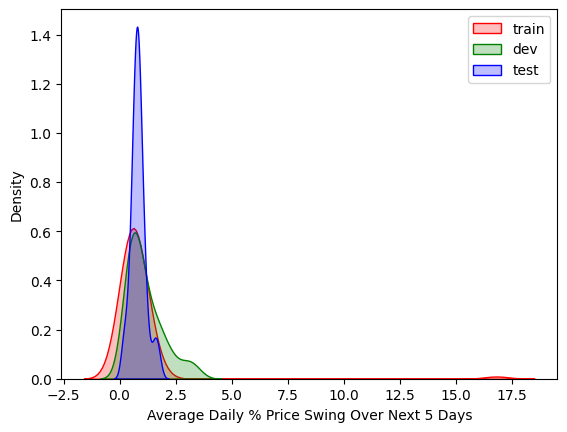

In [11]:
dev_len, test_len = int(len(dataset)/10), int(len(dataset)/10)
train_len = len(dataset)-dev_len-test_len
feat = 'std5'
train_feat = df.iloc[:train_len][feat]
dev_feat = df.iloc[train_len : train_len+dev_len][feat]
test_feat = df.iloc[train_len+dev_len : train_len+dev_len+test_len][feat]
sns.kdeplot(train_feat, shade = True, color='r', label = 'train')
sns.kdeplot(dev_feat, shade = True, color='g', label = 'dev')
sns.kdeplot(test_feat, shade = True, color='b', label = 'test')
plt.xlabel('Average Daily % Price Swing Over Next 5 Days')
plt.legend()
plt.show()

Graph of true 21 day volatility over train (blue), validation (orange), and test (green) period.

<Axes: >

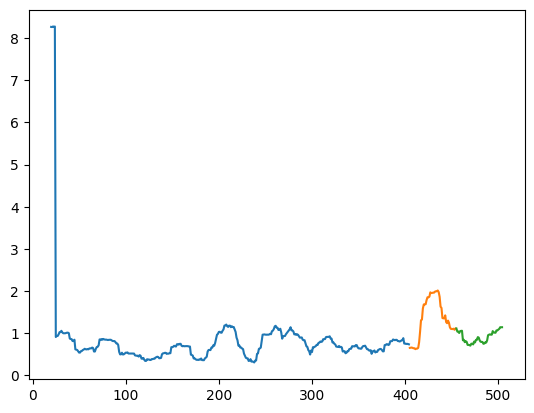

In [12]:
feat = 'std21'
df.iloc[:train_len][feat].plot()
df.iloc[train_len : train_len+dev_len][feat].plot()
df.iloc[train_len+dev_len : train_len+dev_len+test_len][feat].plot()
# df.iloc[train_len+dev_len : train_len+dev_len+test_len][feat].plot()

Graph of true 10 day mean in train, validation, and test sets.

<Axes: >

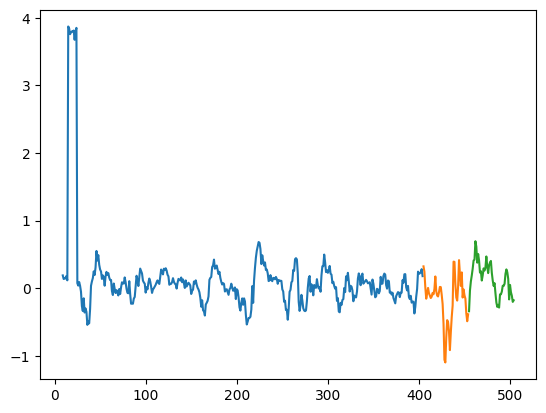

In [13]:
df.iloc[:train_len].r_mean10.plot()
df.iloc[train_len : train_len+dev_len].r_mean10.plot()
df.iloc[train_len+dev_len : train_len+dev_len+test_len].r_mean10.plot()

<Axes: >

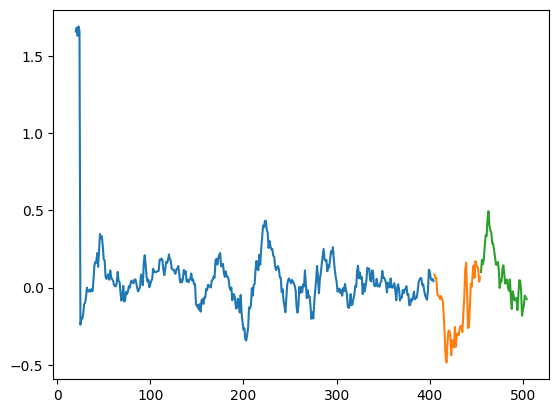

In [14]:
df.iloc[:train_len].r_mean21.plot()
df.iloc[train_len : train_len+dev_len].r_mean21.plot()
df.iloc[train_len+dev_len : train_len+dev_len+test_len].r_mean21.plot()

## Model Output Review

Define directory, build positive negative confusion matrix function.

In [15]:
GRAPH_BUILDING_DIR = os.path.join(ROOT_FOLDER, "code", "graph_building")
def pn_confusion_matrix(output_folder, dataset_name, label="rmean5"):
    model = output_folder.split("\\")[-2]
    
    last_status = pd.read_csv(output_folder+dataset_name+"_last.csv")
    pred= pd.read_csv(output_folder+dataset_name+"_pred.csv")
    true = pd.read_csv(output_folder+dataset_name+"_true.csv")

    df = pd.concat([
        pred[label+'_'+dataset_name+'_pred'],
        true[label+'_'+dataset_name+'_true'],
        last_status[label+'_'+dataset_name+'_last'],
        ], axis=1)
    df.columns = ['pred', 'true', 'last']
    denominator = len(df[(df['last'] == 0) & (df['true'] == 1)])
    numerator = len(df[(df['last'] == 0) & (df['true'] == 1) & (df['pred'] > 0.5)])
    ln_ni = numerator/ denominator
    
    denominator = len(df[(df['last'] == 0) & (df['true'] == 0)])
    numerator = len(df[(df['last'] == 0) & (df['true'] == 0) & (df['pred'] < 0.5)])
    ln_nd = numerator/ denominator

    denominator = len(df[(df['last'] == 1) & (df['true'] == 1)])
    numerator = len(df[(df['last'] == 1) & (df['true'] == 1) & (df['pred'] > 0.5)])
    lp_ni = numerator/ denominator

    denominator = len(df[(df['last'] == 1) & (df['true'] == 0)])
    numerator = len(df[(df['last'] == 1) & (df['true'] == 0) & (df['pred'] < 0.5)])
    lp_nd = numerator/ denominator

    print("Dataset: ", dataset_name, " Model: ", model)
    print("LN_N+ : ", ln_ni, " LP_N+: ", lp_ni)
    print("LN_N- : ", ln_nd, " LP_N-: ", lp_nd)

    return df

## ACL2018 Dataset Review

In [16]:
dataset_name = "ACL2018"

## LSTM Prediction Output Review

In [17]:
ROOT_FOLDER = os.path.abspath(os.path.join(os.getcwd(), "522 Replication Code", "NGAT")) + os.sep
output_folder = os.path.join(ROOT_FOLDER, "code", "notebook", "lstm") + os.sep

print("LSTM Model")
print("Rmean5:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")
print("Rmean10:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")
print("Rmean21:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

LSTM Model
Rmean5:
Dataset:  ACL2018  Model:  lstm
LN_N+ :  0.762796504369538  LP_N+:  0.8051511758118701
LN_N- :  0.7353224254090471  LP_N-:  0.6888472352389878
Rmean10:
Dataset:  ACL2018  Model:  lstm
LN_N+ :  0.773015873015873  LP_N+:  0.8057080131723381
LN_N- :  0.7269076305220884  LP_N-:  0.6737925574030087
Rmean21:
Dataset:  ACL2018  Model:  lstm
LN_N+ :  0.7901498929336188  LP_N+:  0.7819905213270142
LN_N- :  0.6942551119766309  LP_N-:  0.6389719067543336


## NGAT Prediction Output Review

In [18]:
output_folder = os.path.join(ROOT_FOLDER, "code", "notebook", "ngat") + os.sep

print("Rmean5:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")
print("Rmean10:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")
print("Rmean21:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

Rmean5:
Dataset:  ACL2018  Model:  ngat
LN_N+ :  0.7765293383270911  LP_N+:  0.8185890257558791
LN_N- :  0.7998075072184793  LP_N-:  0.7216494845360825
Rmean10:
Dataset:  ACL2018  Model:  ngat
LN_N+ :  0.7380952380952381  LP_N+:  0.823271130625686
LN_N- :  0.7971887550200804  LP_N-:  0.7395091053048297
Rmean21:
Dataset:  ACL2018  Model:  ngat
LN_N+ :  0.7601713062098501  LP_N+:  0.7756714060031595
LN_N- :  0.6923076923076923  LP_N-:  0.6521219366407651


## SPNews Dataset Review

In [19]:
dataset_name = "SPNews"

## LSTM Prediction Output Review

In [20]:
output_folder = os.path.join(ROOT_FOLDER, "code", "notebook", "lstm") + os.sep

print("Rmean5:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")
print("Rmean10:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")
print("Rmean21:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

Rmean5:
Dataset:  SPNews  Model:  lstm
LN_N+ :  0.6691887347625053  LP_N+:  0.6210439786272092
LN_N- :  0.8372093023255814  LP_N-:  0.8320987654320988
Rmean10:
Dataset:  SPNews  Model:  lstm
LN_N+ :  0.6111336854937017  LP_N+:  0.5645330535152151
LN_N- :  0.8126436781609195  LP_N-:  0.8188338010601809
Rmean21:
Dataset:  SPNews  Model:  lstm
LN_N+ :  0.6291713535808025  LP_N+:  0.5858951175406871
LN_N- :  0.7956458635703919  LP_N-:  0.7936614969656103


## NGAT Prediction Output Review

In [21]:
output_folder = os.path.join(ROOT_FOLDER, "code", "notebook", "ngat") + os.sep

print("Rmean5:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean5")
print("Rmean10:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean10")
print("Rmean21:")
df = pn_confusion_matrix(output_folder=output_folder, dataset_name=dataset_name, label="rmean21")

#Note to self: TRY STD INSTEAD OF MEAN

Rmean5:


Dataset:  SPNews  Model:  ngat
LN_N+ :  0.7288776796973518  LP_N+:  0.6773530620632964
LN_N- :  0.8040993299172251  LP_N-:  0.783068783068783
Rmean10:
Dataset:  SPNews  Model:  ngat
LN_N+ :  0.6883380739536774  LP_N+:  0.6657922350472193
LN_N- :  0.7796934865900383  LP_N-:  0.7864047396320549
Rmean21:
Dataset:  SPNews  Model:  ngat
LN_N+ :  0.6914135733033371  LP_N+:  0.5804701627486437
LN_N- :  0.7741654571843251  LP_N-:  0.8024275118004046


These outputs confirm the original paper's findings of the confusion matrix for lstm and NGAT in which NGAT is fairly consistently more accurate than LSTM. 

## Statistical Analysis

In [22]:
# Configuration - change these three variables to switch dataset/model/target type
DATASET = "ACL2018"  #ACL2018 or SPNews (or New Data Generation if run with main_classification.py)
MODEL = "ngat"      #ngat or lstm
Y_TYPE = "mean"     # 'mean' for rmean targets, 'std' for volatility targets

if Y_TYPE == 'mean':
    TARGETS = ['rmean5', 'rmean10', 'rmean21']
else:
    TARGETS = ['std5', 'std10', 'std21']

base_dir = os.path.join(os.getcwd(), MODEL)
pred_fp = os.path.join(base_dir, f"{DATASET}_pred.csv")
true_fp = os.path.join(base_dir, f"{DATASET}_true.csv")
last_fp = os.path.join(base_dir, f"{DATASET}_last.csv")

if not os.path.exists(pred_fp) or not os.path.exists(true_fp):
    print('Prediction or true CSV not found. Expected files:')
    print('  ', pred_fp)
    print('  ', true_fp)
else:
    pred_df = pd.read_csv(pred_fp)
    true_df = pd.read_csv(true_fp)
    last_df = pd.read_csv(last_fp) if os.path.exists(last_fp) else None

    results = []
    for t in TARGETS:
        pred_col = f"{t}_{DATASET}_pred"
        true_col = f"{t}_{DATASET}_true"
        last_col = f"{t}_{DATASET}_last"
        if pred_col not in pred_df.columns or true_col not in true_df.columns:
            print('Skipping', t, '- columns missing in CSVs')
            continue

        y_pred_prob = pred_df[pred_col].values.astype(float)
        y_true = true_df[true_col].values.astype(int)
        y_pred = (y_pred_prob > 0.5).astype(int)

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        try:
            auc = roc_auc_score(y_true, y_pred_prob)
        except Exception:
            auc = np.nan
        mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true))>1 else np.nan
        cm = confusion_matrix(y_true, y_pred).tolist()

        last_acc = None
        improvement = None
        if last_df is not None and last_col in last_df.columns:
            y_last = last_df[last_col].values.astype(int)
            last_acc = accuracy_score(y_true, y_last)
            improvement = acc - last_acc

        results.append({
            'target': t, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc, 'mcc': mcc,
            'confusion_matrix': cm, 'last_acc': last_acc, 'improvement_over_last': improvement,
        })

    # Summary table
    summary = pd.DataFrame([{k:v for k,v in r.items() if k!='confusion_matrix'} for r in results])
    if not summary.empty:
        display(summary.style.format({k: '{:.4f}' for k in ['accuracy','precision','recall','f1','auc','mcc'] if k in summary.columns}))

Prediction or true CSV not found. Expected files:
   c:\Users\quinb\Desktop\UW CFRM\522\Research Paper 1\ngat\ACL2018_pred.csv
   c:\Users\quinb\Desktop\UW CFRM\522\Research Paper 1\ngat\ACL2018_true.csv


## Compare NGAT and LSTM

Model  Target  Accuracy  Precision   Recall       F1      AUC
 NGAT  rmean5  0.777368   0.728202 0.798701 0.761824 0.861708
 NGAT rmean10  0.774474   0.695876 0.788449 0.739276 0.857661
 NGAT rmean21  0.696842   0.485092 0.769091 0.594937 0.783452
 LSTM  rmean5  0.744474   0.686629 0.785124 0.732581 0.831584
 LSTM rmean10  0.735789   0.640945 0.792343 0.708648 0.827995
 LSTM rmean21  0.696316   0.484848 0.785455 0.599584 0.798587
rmean5: NGAT wins by 0.0329 accuracy
rmean10: NGAT wins by 0.0387 accuracy
rmean21: NGAT wins by 0.0005 accuracy


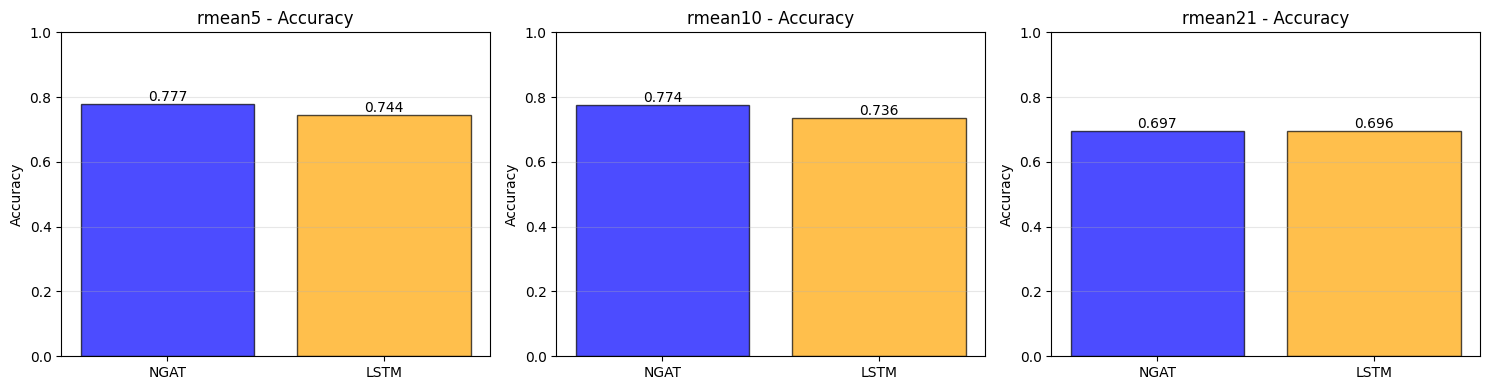


NGAT:
 Target  Accuracy  Precision   Recall       F1      AUC
 rmean5  0.777368   0.728202 0.798701 0.761824 0.861708
rmean10  0.774474   0.695876 0.788449 0.739276 0.857661
rmean21  0.696842   0.485092 0.769091 0.594937 0.783452
  → Average Accuracy: 0.7496
  → Average F1-Score: 0.6987

LSTM:
 Target  Accuracy  Precision   Recall       F1      AUC
 rmean5  0.744474   0.686629 0.785124 0.732581 0.831584
rmean10  0.735789   0.640945 0.792343 0.708648 0.827995
rmean21  0.696316   0.484848 0.785455 0.599584 0.798587
  → Average Accuracy: 0.7255
  → Average F1-Score: 0.6803
mean

NGAT (MEAN) - 3 targets found
--------------------------------------------------------------------------------
 Target  Accuracy     F1  AUC-ROC      R²
 rmean5    0.7774 0.7618   0.8617  0.3786
rmean10    0.7745 0.7393   0.8577  0.3518
rmean21    0.6968 0.5949   0.7835 -0.0051
  Mean Accuracy:  0.7496
  Mean F1-Score:  0.6987

LSTM (MEAN) - 3 targets found
--------------------------------------------------------

In [23]:
# Configuration
DATASET = "ACL2018"
NGAT_MODEL = "ngat"
LSTM_MODEL = "lstm"
Y_TYPES = ["mean", "std"]
Y_TYPE = "mean"
MODELS = [NGAT_MODEL, LSTM_MODEL]
if Y_TYPE == 'mean':
    TARGETS = ['rmean5', 'rmean10', 'rmean21']
else:
    TARGETS = ['std5', 'std10', 'std21']

# Load predictions from both models
results_comparison = []
for model_name in MODELS:
    base_dir = os.path.join(ROOT_FOLDER, "code", "notebook", model_name)
    pred_fp = os.path.join(base_dir, f"{DATASET}_pred.csv")
    true_fp = os.path.join(base_dir, f"{DATASET}_true.csv")
    
    if not os.path.exists(pred_fp) or not os.path.exists(true_fp):
        print(f'Files not found for {model_name}')
        continue
    
    pred_df = pd.read_csv(pred_fp)
    true_df = pd.read_csv(true_fp)
    
    for t in TARGETS:
        pred_col = f"{t}_{DATASET}_pred"
        true_col = f"{t}_{DATASET}_true"
        
        if pred_col not in pred_df.columns or true_col not in true_df.columns:
            continue
        
        y_pred_prob = pred_df[pred_col].values.astype(float)
        y_true = true_df[true_col].values.astype(int)
        y_pred = (y_pred_prob > 0.5).astype(int)
        
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_pred_prob) if len(np.unique(y_true)) > 1 else np.nan
        
        results_comparison.append({
            'Model': model_name.upper(),
            'Target': t,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'AUC': auc
        })

# Create comparison dataframe
comparison_df = pd.DataFrame(results_comparison)

# Display summary table
print(comparison_df.to_string(index=False))

# Statistical comparison per target
for target in TARGETS:
    target_data = comparison_df[comparison_df['Target'] == target]
    if len(target_data) == 2:
        ngat_acc = target_data[target_data['Model'] == 'NGAT']['Accuracy'].values[0]
        lstm_acc = target_data[target_data['Model'] == 'LSTM']['Accuracy'].values[0]
        acc_diff = ngat_acc - lstm_acc
        winner = "NGAT" if acc_diff > 0 else "LSTM"
        print(f"{target}: {winner} wins by {abs(acc_diff):.4f} accuracy")

# Visualization: Accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, target in enumerate(TARGETS):
    target_data = comparison_df[comparison_df['Target'] == target]
    if not target_data.empty:
        models_temp = target_data['Model'].values
        accuracies = target_data['Accuracy'].values
        
        colors = ['blue', 'orange']  # Blue for NGAT, Orange for LSTM
        bars = axes[idx].bar(models_temp, accuracies, color=colors, alpha=0.7, edgecolor='black')
        axes[idx].set_ylim([0, 1])
        axes[idx].set_ylabel('Accuracy')
        axes[idx].set_title(f'{target} - Accuracy')
        axes[idx].grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

for model in [NGAT_MODEL.upper(), LSTM_MODEL.upper()]:
    print(f"\n{model}:")
    model_metrics = comparison_df[comparison_df['Model'] == model]
    print(model_metrics[['Target', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].to_string(index=False))
    
    avg_acc = model_metrics['Accuracy'].mean()
    avg_f1 = model_metrics['F1'].mean()
    print(f"  → Average Accuracy: {avg_acc:.4f}")
    print(f"  → Average F1-Score: {avg_f1:.4f}")

target_mapping = {
    "mean": ['rmean5', 'rmean10', 'rmean21'],
    "std": ['std5', 'std10', 'std21'] 
}

all_results = []
model_summaries = {}


for y_type in Y_TYPES:
    print(y_type)
    
    TARGETS = target_mapping[y_type]
    
    for model_name in MODELS:
        model_upper = model_name.upper()
        base_dir = os.path.join(ROOT_FOLDER, "code", "notebook", model_name)
        pred_fp = os.path.join(base_dir, f"{DATASET}_pred.csv")
        true_fp = os.path.join(base_dir, f"{DATASET}_true.csv")
        
        if not os.path.exists(pred_fp) or not os.path.exists(true_fp):
            print(f'Files not found for {model_upper}')
            continue
        
        pred_df = pd.read_csv(pred_fp)
        true_df = pd.read_csv(true_fp)
        
        model_metrics = []
        targets_found = 0
        
        for target in TARGETS:
            pred_col = f"{target}_{DATASET}_pred"
            true_col = f"{target}_{DATASET}_true"
            
            if pred_col not in pred_df.columns:
                print(f"Missing column: {pred_col}")
                continue
            if true_col not in true_df.columns:
                print(f"Missing column: {true_col}")
                continue
            
            targets_found += 1
            y_pred_prob = pred_df[pred_col].values.astype(float)
            y_true = true_df[true_col].values.astype(int)
            y_pred = (y_pred_prob > 0.5).astype(int)
            
            # Classification metrics
            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            
            # AUC-ROC
            try:
                auc = roc_auc_score(y_true, y_pred_prob)
            except Exception:
                auc = np.nan
            
            # Matthews Correlation Coefficient
            mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
            
            # Regression metrics
            mse = mean_squared_error(y_true, y_pred_prob)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_true, y_pred_prob)
            
            # R^2 Score
            try:
                r2 = r2_score(y_true, y_pred_prob)
            except Exception:
                r2 = np.nan
            
            # Statistical significance test
            if len(y_true) > 1:
                t_stat, p_value = stats.ttest_ind(y_true, y_pred_prob)
            else:
                t_stat, p_value = np.nan, np.nan
            
            # Effect size (Cohen's d)
            if len(y_true) > 1:
                mean_diff = np.mean(y_true) - np.mean(y_pred_prob)
                pooled_std = np.sqrt((np.std(y_true)**2 + np.std(y_pred_prob)**2) / 2)
                cohens_d = mean_diff / pooled_std if pooled_std != 0 else 0
            else:
                cohens_d = np.nan
            
            model_metrics.append({
                'Model': model_upper,
                'Y_Type': y_type.upper(),
                'Target': target,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1': f1,
                'AUC-ROC': auc,
                'MCC': mcc,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R²': r2,
                'T-Statistic': t_stat,
                'P-Value': p_value,
                "Cohen's D": cohens_d,
                'N_Samples': len(y_true)
            })
            
            all_results.append(model_metrics[-1])
            
            # Memory cleanup
            del y_pred_prob, y_true, y_pred
            gc.collect()
        
        # Print model-specific summary
        if model_metrics:
            model_df = pd.DataFrame(model_metrics)
            print(f"\n{model_upper} ({y_type.upper()}) - {targets_found} targets found")
            print("-" * 80)
            print(model_df[['Target', 'Accuracy', 'F1', 'AUC-ROC', 'R²']].to_string(index=False, 
                float_format=lambda x: f'{x:.4f}' if not np.isnan(x) else 'N/A'))
            print(f"  Mean Accuracy:  {model_df['Accuracy'].mean():.4f}")
            print(f"  Mean F1-Score:  {model_df['F1'].mean():.4f}")

# Results Summary
if all_results:
    full_df = pd.DataFrame(all_results)
    for y_type in Y_TYPES:
        ytype_data = full_df[full_df['Y_Type'] == y_type.upper()]
        if not ytype_data.empty:
            print(f"\n{y_type.upper()}:")
            print(ytype_data.groupby('Model')[['Accuracy', 'F1', 'R²']].mean().to_string(
                float_format=lambda x: f'{x:.4f}'))
else:
    print("\nNO RESULTS FOUND - check for missing files or columns")

Accuracy measures how often the model is correct overall, precision measures how often the model accurately predicts positive, and recall measures how often the model catches a true positive. LSTM rmean10 and rmean21 have better recall than NGAT rmean10 and rmean21 by 0.5% and 2% respectively. The F1 score (score of machine learning accuracy from precision and recall) for rmean21 in LSTM is better than the F1 score for NGAT rmean21 by 0.78%. 

In [24]:
import statsmodels.api as sm
regression_results = []
model_comparison = []

for y_type in Y_TYPES:
    
    TARGETS = target_mapping[y_type]
    
    # Load predictions for both models
    model_data = {}
    
    for model_name in MODELS:
        model_upper = model_name.upper()
        base_dir = os.path.join(ROOT_FOLDER, "code", "notebook", model_name)
        pred_fp = os.path.join(base_dir, f"{DATASET}_pred.csv")
        true_fp = os.path.join(base_dir, f"{DATASET}_true.csv")
        
        if not os.path.exists(pred_fp) or not os.path.exists(true_fp):
            print(f' Files not found for {model_upper}')
            continue
        
        pred_df = pd.read_csv(pred_fp)
        true_df = pd.read_csv(true_fp)
        
        model_data[model_name] = {'pred': pred_df, 'true': true_df}
    
    if len(model_data) < 2:
        print("Both models required for comparison")
        continue
    
    # regression analysis  for all TARGETS
    for target in TARGETS:
        
        pred_col = f"{target}_{DATASET}_pred"
        true_col = f"{target}_{DATASET}_true"
        
        # Extract predictions and actuals for both models
        ngat_pred = model_data['ngat']['pred'][pred_col].values.astype(float)
        lstm_pred = model_data['lstm']['pred'][pred_col].values.astype(float)
        y_true = model_data['ngat']['true'][true_col].values.astype(int)
        
        # Ensure same length
        min_len = min(len(ngat_pred), len(lstm_pred), len(y_true))
        ngat_pred = ngat_pred[:min_len]
        lstm_pred = lstm_pred[:min_len]
        y_true = y_true[:min_len]
        
        # Convert to binary predictions
        ngat_binary = (ngat_pred > 0.5).astype(int)
        lstm_binary = (lstm_pred > 0.5).astype(int)
        
        # Model 1: Linear Regression - NGAT prediction accuracy 
        ngat_squared_error = (y_true - ngat_pred) ** 2
        
        X_ngat = sm.add_constant(ngat_pred)
        model_ngat = sm.OLS(y_true, X_ngat).fit()
        
        print("NGAT Model - Predicting True Labels from NGAT Probabilities:")
        print(model_ngat.summary())
        print()
        
        # Model 2: Linear Regression - LSTM prediction accuracy 
        lstm_squared_error = (y_true - lstm_pred) ** 2
        
        X_lstm = sm.add_constant(lstm_pred)
        model_lstm = sm.OLS(y_true, X_lstm).fit()
        
        print("LSTM Model - Predicting True Labels from LSTM Probabilities:")
        print(model_lstm.summary())
        print()
        
        # Model 3: Regression with Model Indicator (NGAT vs LSTM) 
        print(f"\nDirect Model Comparison - {target}:")
        
        # Stack predictions and create model indicator
        predictions_combined = np.concatenate([ngat_pred, lstm_pred])
        model_indicator = np.concatenate([np.zeros(len(ngat_pred)), np.ones(len(lstm_pred))])  # 0=NGAT, 1=LSTM
        y_true_doubled = np.concatenate([y_true, y_true])
        
        # Regression: y_true ~ predictions + model_indicator + interaction
        X_comparison = sm.add_constant(np.column_stack([predictions_combined, model_indicator, predictions_combined * model_indicator]))
        model_comparison_reg = sm.OLS(y_true_doubled, X_comparison).fit()
        
        print("Regression: True Labels ~ Predictions + Model (0=NGAT, 1=LSTM) + Interaction")
        print(model_comparison_reg.summary())
        
        
        model_pvalue = model_comparison_reg.pvalues[2]
        
        print(f"\nModel Indicator P-value: {model_pvalue:.6f}")
        if model_pvalue < 0.05:
            print(f"   SIGNIFICANT difference between NGAT and LSTM (p < 0.05)")
        else:
            print(f"   NO significant difference between NGAT and LSTM (p >= 0.05)")
        print()
        
        ngat_acc = accuracy_score(y_true, ngat_binary)
        lstm_acc = accuracy_score(y_true, lstm_binary)
        acc_diff = ngat_acc - lstm_acc
        
        ngat_mse = mean_squared_error(y_true, ngat_pred)
        lstm_mse = mean_squared_error(y_true, lstm_pred)
        mse_diff = lstm_mse - ngat_mse  # positive = NGAT is better (lower MSE)
        
        ngat_r2 = model_ngat.rsquared
        lstm_r2 = model_lstm.rsquared
        
        t_stat, t_pval = stats.ttest_rel(ngat_squared_error, lstm_squared_error)
        
        print(f"   NGAT Accuracy: {ngat_acc:.4f}")
        print(f"   LSTM Accuracy: {lstm_acc:.4f}")
        print(f"   Difference (NGAT - LSTM): {acc_diff:+.4f}")
        print()
        
        print(f"   NGAT MSE: {ngat_mse:.6f}")
        print(f"   LSTM MSE: {lstm_mse:.6f}")
        print(f"   Difference (LSTM - NGAT): {mse_diff:+.6f}")
        print()
        
        print(f"   NGAT R²: {ngat_r2:.4f}")
        print(f"   LSTM R²: {lstm_r2:.4f}")
        print()
        
        print(f"   t-statistic: {t_stat:.4f}")
        print(f"   p-value: {t_pval:.6f}")
        if t_pval < 0.05:
            winner = "NGAT" if t_stat > 0 else "LSTM"
            print(f"   SIGNIFICANT (p < 0.05): {winner} has significantly lower errors")
        else:
            print(f"   NOT significant (p >= 0.05): No statistical difference in errors")
        print()
        
        # Store results
        regression_results.append({
            'Y_Type': y_type.upper(),
            'Target': target,
            'NGAT_Acc': ngat_acc,
            'LSTM_Acc': lstm_acc,
            'Acc_Diff': acc_diff,
            'NGAT_MSE': ngat_mse,
            'LSTM_MSE': lstm_mse,
            'MSE_Diff': mse_diff,
            'NGAT_R2': ngat_r2,
            'LSTM_R2': lstm_r2,
            'Model_Indicator_PValue': model_pvalue,
            'Paired_T_PValue': t_pval,
            'T_Statistic': t_stat,
            'Paired_T_Winner': "NGAT" if t_stat > 0 else "LSTM"
        })
        
        model_comparison.append({
            'Y_Type': y_type.upper(),
            'Target': target,
            'Model': 'NGAT',
            'Accuracy': ngat_acc,
            'MSE': ngat_mse,
            'R²': ngat_r2
        })
        model_comparison.append({
            'Y_Type': y_type.upper(),
            'Target': target,
            'Model': 'LSTM',
            'Accuracy': lstm_acc,
            'MSE': lstm_mse,
            'R^2': lstm_r2
        })

if regression_results:
    results_df = pd.DataFrame(regression_results)
    print(results_df[[
        'Y_Type', 'Target', 'NGAT_Acc', 'LSTM_Acc', 'Acc_Diff',
        'NGAT_MSE', 'LSTM_MSE', 'Model_Indicator_PValue', 'Paired_T_PValue', 'Paired_T_Winner'
    ]].to_string(index=False, float_format=lambda x: f'{x:.6f}' if abs(x) < 1 else f'{x:.4f}'))
    
    # --- Hypothesis test summary ---
    print("HYPOTHESIS TEST: Is NGAT significantly better than LSTM?")
    
    # Count wins
    ngat_wins = (results_df['Paired_T_Winner'] == 'NGAT').sum()
    lstm_wins = (results_df['Paired_T_Winner'] == 'LSTM').sum()
    
    print(f"Paired t-test results (squared error comparison):")
    print(f"  NGAT wins (lower error): {ngat_wins}/{len(results_df)}")
    print(f"  LSTM wins (lower error): {lstm_wins}/{len(results_df)}")
    print()
    
    # Aggregate p-value using Fisher's method
    import scipy.stats as sp_stats
    pvalues = results_df['Paired_T_PValue'].values
    chi2_stat = -2 * np.sum(np.log(pvalues))
    combined_pval = 1 - sp_stats.chi2.cdf(chi2_stat, 2 * len(pvalues))
    
    print(f"Fisher's combined p-value (across all targets): {combined_pval:.6f}")
    if combined_pval < 0.05:
        print(f"GOOD: NGAT is statistically significantly better than LSTM (p < 0.05)")
    else:
        print(f"BAD: No statistically significant overall difference (p >= 0.05)")
    
    print()
    print("Model Indicator P-values (direct regression comparison):")
    for _, row in results_df.iterrows():
        sig = "✓" if row['Model_Indicator_PValue'] < 0.05 else "✗"
        print(f"  {sig} {row['Y_Type']}/{row['Target']}: p={row['Model_Indicator_PValue']:.6f}")
    
    # Visualization
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle('NGAT vs LSTM Model Comparison', fontsize=16, fontweight='bold')
    
    comparison_df = pd.DataFrame(model_comparison)
    
    for idx, y_type in enumerate(Y_TYPES):
        # Accuracy comparison
        ax = axes[idx, 0]
        y_plot = comparison_df[comparison_df['Y_Type'] == y_type.upper()]
        targets_plot = y_plot['Target'].unique()
        ngat_accs = y_plot[y_plot['Model'] == 'NGAT'].set_index('Target').loc[targets_plot, 'Accuracy'].values
        lstm_accs = y_plot[y_plot['Model'] == 'LSTM'].set_index('Target').loc[targets_plot, 'Accuracy'].values
        
        x = np.arange(len(targets_plot))
        width = 0.35
        ax.bar(x - width/2, ngat_accs, width, label='NGAT', alpha=0.8, color='#1f77b4')
        ax.bar(x + width/2, lstm_accs, width, label='LSTM', alpha=0.8, color='#ff7f0e')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'Accuracy - {y_type.upper()}')
        ax.set_xticks(x)
        ax.set_xticklabels(targets_plot)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # MSE comparison
        ax = axes[idx, 1]
        ngat_mses = y_plot[y_plot['Model'] == 'NGAT'].set_index('Target').loc[targets_plot, 'MSE'].values
        lstm_mses = y_plot[y_plot['Model'] == 'LSTM'].set_index('Target').loc[targets_plot, 'MSE'].values
        
        ax.bar(x - width/2, ngat_mses, width, label='NGAT', alpha=0.8, color='#1f77b4')
        ax.bar(x + width/2, lstm_mses, width, label='LSTM', alpha=0.8, color='#ff7f0e')
        ax.set_ylabel('MSE (lower is better)')
        ax.set_title(f'MSE - {y_type.upper()}')
        ax.set_xticks(x)
        ax.set_xticklabels(targets_plot)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        # R² comparison
        ax = axes[idx, 2]
        ngat_r2s = y_plot[y_plot['Model'] == 'NGAT'].set_index('Target').loc[targets_plot, 'R²'].values
        lstm_r2s = y_plot[y_plot['Model'] == 'LSTM'].set_index('Target').loc[targets_plot, 'R²'].values
        
        ax.bar(x - width/2, ngat_r2s, width, label='NGAT', alpha=0.8, color='#1f77b4')
        ax.bar(x + width/2, lstm_r2s, width, label='LSTM', alpha=0.8, color='#ff7f0e')
        ax.set_ylabel('R² (higher is better)')
        ax.set_title(f'R² - {y_type.upper()}')
        ax.set_xticks(x)
        ax.set_xticklabels(targets_plot)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\nRegression analysis complete!")

NGAT Model - Predicting True Labels from NGAT Probabilities:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     2426.
Date:                Sun, 08 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:23:50   Log-Likelihood:                -1797.0
No. Observations:                3800   AIC:                             3598.
Df Residuals:                    3798   BIC:                             3611.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

KeyError: 'std5_ACL2018_pred'

# Important Notes
My computer could not run predict.py for SPNews due to memory errors, so Prediction.xlsx is for ACL2018 only. I ran ACL2018 mean predictions successfully, but ACL2018 standard deviation predictions are too memory intensive, however they are needed for proper analysis. If a full analysis is wanted, run "data_interpreter.py" located in the overall "code" folder. It should be run with "Y_Type = A" for A = (mean, std) as well as "name = B" where B is ACL2018, SPNews, or New Data Generation. My computer was able to train the model but not run the prediction for that set since my GPU cannot take over the task. <br>

In [25]:
# Create dummy news files
import pandas as pd
import os

news_dir = "NGAT/data/raw/NewData/news/preprocessed_daily_2/"
os.makedirs(news_dir, exist_ok=True)

dates = pd.date_range(start="2023-01-01", end="2025-02-06", freq='D')

for date in dates:
    df = pd.DataFrame(columns=['Id', 'Company', 'Date', 'Title', 'Publisher', 'Link', 'ProviderPublishTime', 'Type', 'Related Company', 'Text'])
    df.to_csv(f"{news_dir}{date.strftime('%Y-%m-%d')}.csv", index=False)



Building a simpler model for comparison using Ridge regression; estimate linear regression while addressing multicollinnearity by adding a penalty to the ML loss function. 

In [26]:

import glob
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

PRICE_DIR = os.path.join(ROOT_FOLDER, "data", "raw", "ACL2018", "price", "raw") + os.sep

# params
LOOKBACK = 20            # days to build features
HORIZON = 5              # predict mean return over next HORIZON days
CORR_WINDOW = 252        # window to compute price correlations
CORR_THRESHOLD = 0.2
ALPHA = 1.0              # Ridge regularization

# load prices (Adj Close) into a single DataFrame aligned by Date
files = sorted(glob.glob(os.path.join(PRICE_DIR, "*.csv")))
if not files:
    raise SystemExit("No price CSVs found in " + PRICE_DIR)

price_frames = []
tickers = []
for fp in files:
    df = pd.read_csv(fp, parse_dates=["Date"])
    if "Adj Close" not in df.columns:
        continue
    ticker = os.path.splitext(os.path.basename(fp))[0]
    tickers.append(ticker)
    df = df[["Date", "Adj Close"]].rename(columns={"Adj Close": ticker})
    price_frames.append(df.set_index("Date"))

prices = pd.concat(price_frames, axis=1).sort_index().ffill().dropna(how="all")
# daily log returns (%)
rets = 100 * np.log(prices / prices.shift(1))

# correlation adjacency using rolling window
corr_series = rets.dropna().iloc[-CORR_WINDOW:]
corr_mat = corr_series.corr().fillna(0).values
# threshold to adjacency
adj = (np.abs(corr_mat) >= CORR_THRESHOLD).astype(float) * corr_mat

dates = rets.index
X_rows = []
y_rows = []
meta = []

for i_date in range(LOOKBACK, len(dates) - HORIZON):
    t = dates[i_date]
    look_idx = slice(i_date - LOOKBACK + 1, i_date + 1)  
    future_idx = slice(i_date + 1, i_date + 1 + HORIZON)
    window_rets = rets.iloc[look_idx].values  
    future_rets = rets.iloc[future_idx].values  
    if np.isnan(window_rets).any() or np.isnan(future_rets).any():
        # skip dates with missing values
        continue
    # mean, std, last return of each window
    mean_own = window_rets.mean(axis=0)            
    std_own = window_rets.std(axis=0)              
    last_ret = window_rets[-1, :]                  
    # neighbor aggregated = weighted sum of neighbor * mean return
    neigh_mean = (adj * mean_own).sum(axis=1)      
    degree = (adj != 0).sum(axis=1)
    target_mean = future_rets.mean(axis=0)        
    for idx, ticker in enumerate(tickers):
        feat = [
            mean_own[idx],
            std_own[idx],
            last_ret[idx],
            neigh_mean[idx],
            degree[idx],
        ]
        X_rows.append(feat)
        y_rows.append(target_mean[idx])
        meta.append((t, ticker))

X = np.array(X_rows)
y = np.array(y_rows)

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta, test_size=0.2, random_state=0
)
model = Ridge(alpha=ALPHA)
model.fit(X_train, y_train)
pred = model.predict(X_test)

mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

df_out = pd.DataFrame({
    "date": [m[0] for m in meta_test],
    "ticker": [m[1] for m in meta_test],
    "y_true": y_test,
    "y_pred": pred
})
per_ticker = df_out.groupby("ticker").apply(lambda g: pd.Series({
    "MSE": mean_squared_error(g.y_true, g.y_pred),
    "R2": r2_score(g.y_true, g.y_pred) if len(g)>1 else np.nan,
    "N": len(g)
})).sort_values("MSE")

y_true_dir = (y_test > 0).astype(int)

# Predicted direction: sign of regression output
y_pred_dir = (pred > 0).astype(int)

# Overall accuracy
acc = accuracy_score(y_true_dir, y_pred_dir)

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_true_dir, y_pred_dir)

# Confusion matrix for intuition
tn, fp, fn, tp = confusion_matrix(y_true_dir, y_pred_dir).ravel()

print(f"Accuracy: {acc:.4f}")
print(f"MCC: {mcc:.4f}")

print("\nConfusion Matrix:")
print(f"TP       {tp}")
print(f"FP       {fp}")
print(f"FN       {fn}")
print(f"TN       {tn}")

Accuracy: 0.5439
MCC: 0.0222

Confusion Matrix:
TP       2516
FP       2101
FN       83
TN       88


The simplified model has an accuracy of 0.5439. An accuracy of around 0.5 is random guessing, while worse is considered worse than random guessing. This may be because the simplified model does not take News into account, although an accuracy of 0.54 is absymal. 